In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import gammaln
import statsmodels.api as sm


In [2]:
df = pd.read_csv("blueprinty.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))


Shape: (1500, 4)

Columns:
['patents', 'region', 'age', 'iscustomer']

First 5 rows:


,patents,region,age,iscustomer
0,0,Midwest,32.5,0
1,3,Southwest,37.5,0
2,4,Northwest,27.0,1
3,3,Northeast,24.5,0
4,3,Southwest,37.0,0



Data types:
patents         int64
region         object
age           float64
iscustomer      int64
dtype: object

Missing values:
patents       0
region        0
age           0
iscustomer    0
dtype: int64

Summary statistics:


,patents,region,age,iscustomer
count,1500.000000,1500,1500.000000,1500.000000
unique,NaN,5,NaN,NaN
top,NaN,Northeast,NaN,NaN
freq,NaN,601,NaN,NaN
mean,3.684667,NaN,26.357667,0.320667
std,2.352500,NaN,7.242528,0.466889
min,0.000000,NaN,9.000000,0.000000
25%,2.000000,NaN,21.000000,0.000000
50%,3.000000,NaN,26.000000,0.000000
75%,5.000000,NaN,31.625000,1.000000


In [3]:
group_means = df.groupby("iscustomer")["patents"].mean()
group_counts = df.groupby("iscustomer")["patents"].count()

print("Mean patents by customer status:")
print(group_means)

print("\nCount by customer status:")
print(group_counts)


Mean patents by customer status:
iscustomer
0    3.473013
1    4.133056
Name: patents, dtype: float64

Count by customer status:
iscustomer
0    1019
1     481
Name: patents, dtype: int64


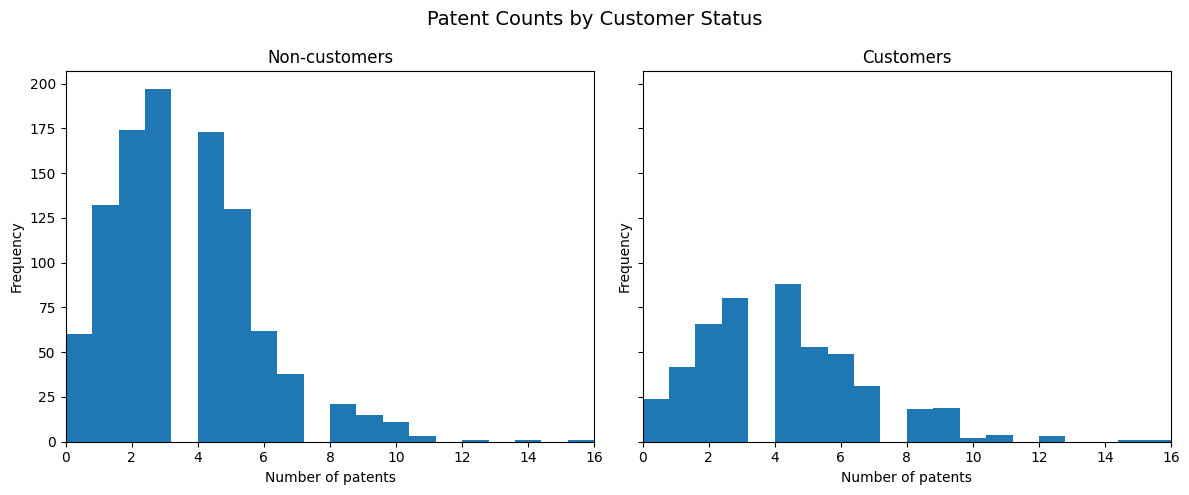

Mean patents for non-customers: 3.4730127576054954
Mean patents for customers: 4.133056133056133


In [4]:
customer_df = df[df["iscustomer"] == 1]
noncustomer_df = df[df["iscustomer"] == 0]

x_min = df["patents"].min()
x_max = df["patents"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].hist(noncustomer_df["patents"], bins=20)
axes[0].set_title("Non-customers")
axes[0].set_xlabel("Number of patents")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(x_min, x_max)

axes[1].hist(customer_df["patents"], bins=20)
axes[1].set_title("Customers")
axes[1].set_xlabel("Number of patents")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(x_min, x_max)

plt.suptitle("Patent Counts by Customer Status", fontsize=14)
plt.tight_layout()
plt.show()

print("Mean patents for non-customers:", noncustomer_df["patents"].mean())
print("Mean patents for customers:", customer_df["patents"].mean())


Region counts by customer status:


iscustomer,0,1
region,,
Midwest,187,37
Northeast,273,328
Northwest,158,29
South,156,35
Southwest,245,52


Region proportions by customer status:


iscustomer,0,1
region,,
Midwest,0.183513,0.076923
Northeast,0.267910,0.681913
Northwest,0.155054,0.060291
South,0.153091,0.072765
Southwest,0.240432,0.108108


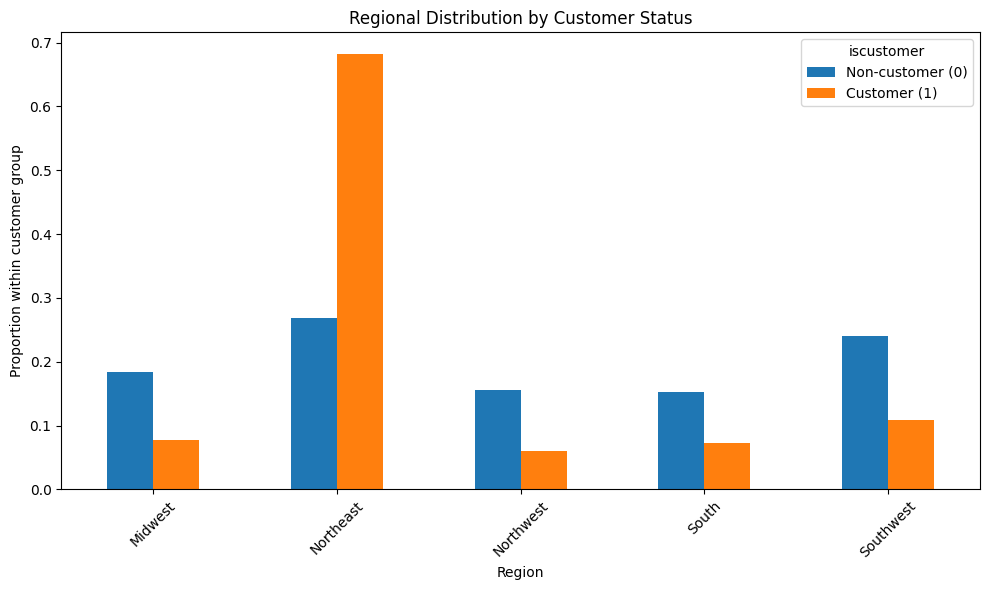

In [5]:
region_counts = pd.crosstab(df["region"], df["iscustomer"])
region_props = pd.crosstab(df["region"], df["iscustomer"], normalize="columns")

print("Region counts by customer status:")
display(region_counts)

print("Region proportions by customer status:")
display(region_props)

region_props.plot(kind="bar", figsize=(10, 6))
plt.title("Regional Distribution by Customer Status")
plt.xlabel("Region")
plt.ylabel("Proportion within customer group")
plt.legend(["Non-customer (0)", "Customer (1)"], title="iscustomer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


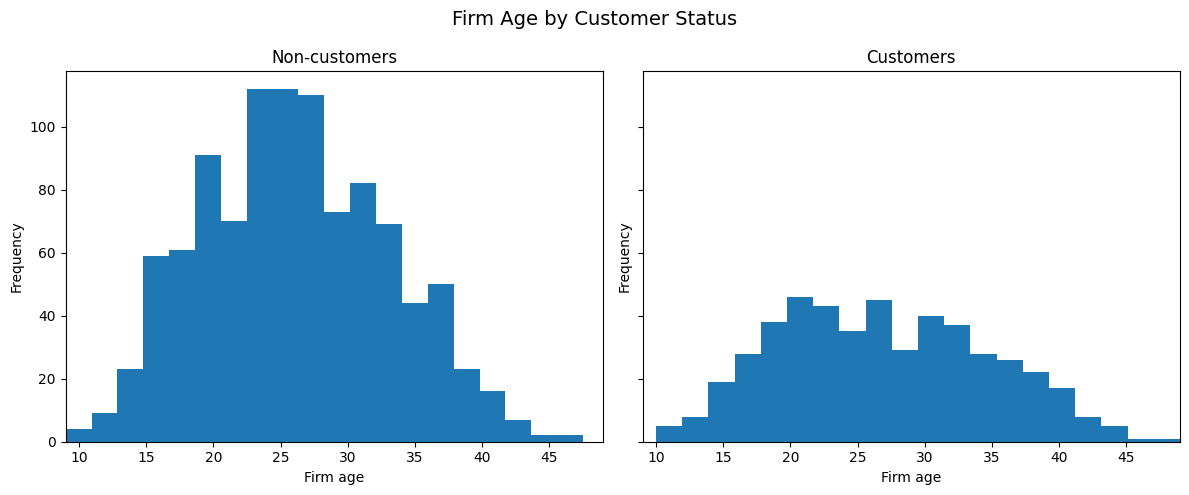

Mean age for non-customers: 26.101570166830225
Mean age for customers: 26.9002079002079


In [6]:
age_min = df["age"].min()
age_max = df["age"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].hist(noncustomer_df["age"], bins=20)
axes[0].set_title("Non-customers")
axes[0].set_xlabel("Firm age")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(age_min, age_max)

axes[1].hist(customer_df["age"], bins=20)
axes[1].set_title("Customers")
axes[1].set_xlabel("Firm age")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(age_min, age_max)

plt.suptitle("Firm Age by Customer Status", fontsize=14)
plt.tight_layout()
plt.show()

print("Mean age for non-customers:", noncustomer_df["age"].mean())
print("Mean age for customers:", customer_df["age"].mean())


In [7]:
Y = df["patents"].values


def poisson_loglikelihood(lam, Y):
    """
    Poisson log-likelihood for iid Y ~ Poisson(lambda)
    lam: scalar > 0
    Y: numpy array of counts
    """
    if lam <= 0:
        return -np.inf
    return np.sum(Y * np.log(lam) - lam - gammaln(Y + 1))


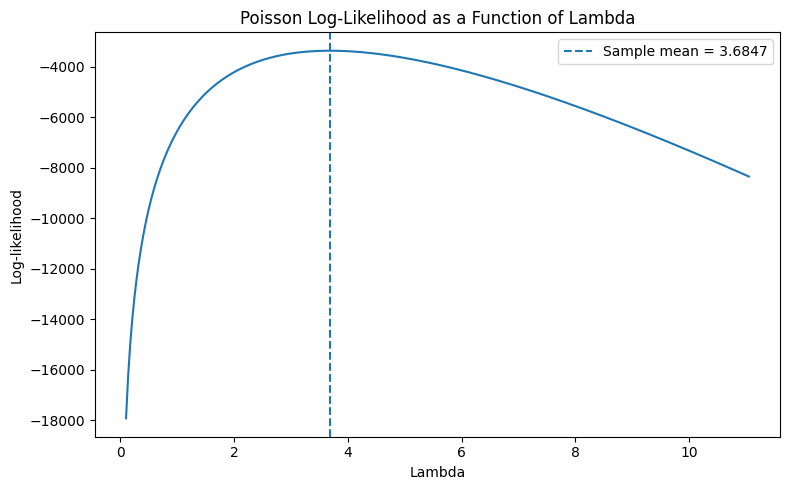

Sample mean of patents: 3.6846666666666668


In [8]:
lam_grid = np.linspace(0.1, Y.mean() * 3, 300)
loglik_values = [poisson_loglikelihood(lam, Y) for lam in lam_grid]

plt.figure(figsize=(8, 5))
plt.plot(lam_grid, loglik_values)
plt.axvline(Y.mean(), linestyle="--", label=f"Sample mean = {Y.mean():.4f}")
plt.title("Poisson Log-Likelihood as a Function of Lambda")
plt.xlabel("Lambda")
plt.ylabel("Log-likelihood")
plt.legend()
plt.tight_layout()
plt.show()

print("Sample mean of patents:", Y.mean())


In [9]:
def neg_poisson_loglikelihood(lam_array, Y):
    lam = lam_array[0]
    if lam <= 0:
        return 1e12
    return -poisson_loglikelihood(lam, Y)


initial_lambda = np.array([Y.mean()])

result_lambda = minimize(
    neg_poisson_loglikelihood,
    x0=initial_lambda,
    args=(Y,),
    method="L-BFGS-B",
    bounds=[(1e-8, None)],
)

lambda_mle_numeric = result_lambda.x[0]

print("Optimization success:", result_lambda.success)
print("Message:", result_lambda.message)
print("Numerical MLE for lambda:", lambda_mle_numeric)
print("Sample mean:", Y.mean())
print("Difference:", lambda_mle_numeric - Y.mean())


Optimization success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Numerical MLE for lambda: 3.6846666675617414
Sample mean: 3.6846666666666668
Difference: 8.950746810398869e-10


In [10]:
df_model = df.copy()
df_model["age_sq"] = df_model["age"] ** 2

region_dummies = pd.get_dummies(df_model["region"], prefix="region", drop_first=True)

X_df = pd.concat(
    [
        pd.Series(1, index=df_model.index, name="intercept"),
        df_model[["age", "age_sq", "iscustomer"]],
        region_dummies,
    ],
    axis=1,
)

X = X_df.astype(float).values
Y = df_model["patents"].astype(float).values

print("Design matrix shape:", X.shape)
display(X_df.head())


Design matrix shape: (1500, 8)


,intercept,age,age_sq,iscustomer,region_Northeast,region_Northwest,region_South,region_Southwest
0,1,32.5,1056.25,0,False,False,False,False
1,1,37.5,1406.25,0,False,False,False,True
2,1,27.0,729.00,1,False,True,False,False
3,1,24.5,600.25,0,True,False,False,False
4,1,37.0,1369.00,0,False,False,False,True


In [11]:
def poisson_regression_loglikelihood(beta, Y, X):
    """
    Log-likelihood for Poisson regression:
    Y_i ~ Poisson(lambda_i), lambda_i = exp(X_i beta)
    """
    eta = X @ beta
    lam = np.exp(eta)
    ll = np.sum(Y * eta - lam - gammaln(Y + 1))
    return ll


def neg_poisson_regression_loglikelihood(beta, Y, X):
    return -poisson_regression_loglikelihood(beta, Y, X)


In [12]:
k = X.shape[1]
beta_init = np.zeros(k)

result_beta = minimize(
    neg_poisson_regression_loglikelihood, x0=beta_init, args=(Y, X), method="BFGS"
)

beta_hat = result_beta.x

print("Optimization success:", result_beta.success)
print("Message:", result_beta.message)
print("\nEstimated beta:")
for name, val in zip(X_df.columns, beta_hat):
    print(f"{name}: {val:.6f}")


Optimization success: False
Message: Desired error not necessarily achieved due to precision loss.

Estimated beta:
intercept: 0.000000
age: 0.000000
age_sq: 0.000000
iscustomer: 0.000000
region_Northeast: 0.000000
region_Northwest: 0.000000
region_South: 0.000000
region_Southwest: 0.000000


/tmp/ipykernel_21700/2855093378.py:7: RuntimeWarning: overflow encountered in exp
  lam = np.exp(eta)
/opt/base-uv/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/base-uv/.venv/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/tmp/ipykernel_21700/2855093378.py:7: RuntimeWarning: overflow encountered in exp
  lam = np.exp(eta)


In [13]:
cov_matrix = result_beta.hess_inv
standard_errors = np.sqrt(np.diag(cov_matrix))

results_table_manual = pd.DataFrame(
    {"variable": X_df.columns, "coef_manual": beta_hat, "se_manual": standard_errors}
)

display(results_table_manual)


,variable,coef_manual,se_manual
0,intercept,0.0,1.0
1,age,0.0,1.0
2,age_sq,0.0,1.0
3,iscustomer,0.0,1.0
4,region_Northeast,0.0,1.0
5,region_Northwest,0.0,1.0
6,region_South,0.0,1.0
7,region_Southwest,0.0,1.0


In [14]:
glm_model = sm.GLM(Y, X, family=sm.families.Poisson())
glm_results = glm_model.fit()

print(glm_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1500
Model:                            GLM   Df Residuals:                     1492
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3258.1
Date:                Mon, 18 May 2026   Deviance:                       2143.3
Time:                        07:16:54   Pearson chi2:                 2.07e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1360
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5089      0.183     -2.778      0.0

In [15]:
results_table_compare = pd.DataFrame(
    {
        "variable": X_df.columns,
        "coef_manual": beta_hat,
        "se_manual": standard_errors,
        "coef_glm": glm_results.params,
        "se_glm": glm_results.bse,
    }
)

display(results_table_compare)

print(
    "Maximum absolute difference in coefficients:",
    np.max(np.abs(beta_hat - glm_results.params)),
)


,variable,coef_manual,se_manual,coef_glm,se_glm
0,intercept,0.0,1.0,-0.508920,0.183179
1,age,0.0,1.0,0.148619,0.013869
2,age_sq,0.0,1.0,-0.002970,0.000258
3,iscustomer,0.0,1.0,0.207591,0.030895
4,region_Northeast,0.0,1.0,0.029170,0.043625
5,region_Northwest,0.0,1.0,-0.017575,0.053781
6,region_South,0.0,1.0,0.056561,0.052662
7,region_Southwest,0.0,1.0,0.050576,0.047198


Maximum absolute difference in coefficients: 0.5089198372970073


In [16]:
customer_coef_manual = results_table_compare.loc[
    results_table_compare["variable"] == "iscustomer", "coef_manual"
].values[0]

customer_coef_glm = results_table_compare.loc[
    results_table_compare["variable"] == "iscustomer", "coef_glm"
].values[0]

print("Manual iscustomer coefficient:", customer_coef_manual)
print("GLM iscustomer coefficient:", customer_coef_glm)

print("\nMultiplicative effect on expected patents:")
print("exp(beta_customer) =", np.exp(customer_coef_glm))

print("\nApproximate percent effect:")
print("100 * (exp(beta_customer) - 1) =", 100 * (np.exp(customer_coef_glm) - 1))


Manual iscustomer coefficient: 0.0
GLM iscustomer coefficient: 0.2075907620040053

Multiplicative effect on expected patents:
exp(beta_customer) = 1.2307094134238235

Approximate percent effect:
100 * (exp(beta_customer) - 1) = 23.070941342382344


In [17]:
X0_df = X_df.copy()
X1_df = X_df.copy()

X0_df["iscustomer"] = 0
X1_df["iscustomer"] = 1

X0 = X0_df.values.astype(float)
X1 = X1_df.values.astype(float)


In [18]:
beta_for_prediction = glm_results.params  # 用GLM结果做预测，更稳

yhat_0 = np.exp(X0 @ beta_for_prediction)
yhat_1 = np.exp(X1 @ beta_for_prediction)

treatment_effect = np.mean(yhat_1 - yhat_0)

print("Average treatment effect of being a Blueprinty customer:")
print(treatment_effect)


Average treatment effect of being a Blueprinty customer:
0.7927680710452771


In [19]:
print("Average predicted patents if all firms were non-customers:", np.mean(yhat_0))
print("Average predicted patents if all firms were customers:", np.mean(yhat_1))
print("Average effect (customer - non-customer):", treatment_effect)


Average predicted patents if all firms were non-customers: 3.4362190050257153
Average predicted patents if all firms were customers: 4.228987076070992
Average effect (customer - non-customer): 0.7927680710452771


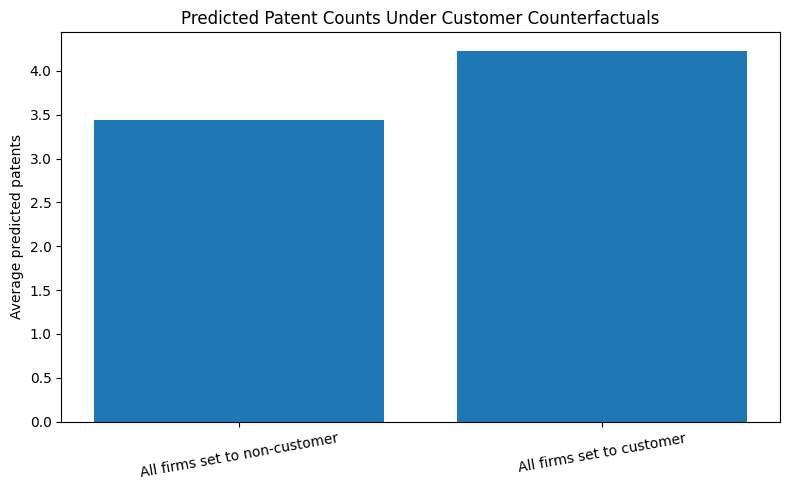

,scenario,mean_predicted_patents
0,All firms set to non-customer,3.436219
1,All firms set to customer,4.228987


In [20]:
summary_df = pd.DataFrame(
    {
        "scenario": ["All firms set to non-customer", "All firms set to customer"],
        "mean_predicted_patents": [np.mean(yhat_0), np.mean(yhat_1)],
    }
)

plt.figure(figsize=(8, 5))
plt.bar(summary_df["scenario"], summary_df["mean_predicted_patents"])
plt.title("Predicted Patent Counts Under Customer Counterfactuals")
plt.ylabel("Average predicted patents")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

display(summary_df)
